In [1]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from trees.data import Data
from trees.causal_tree import CT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

K = 5
w = 0.6
N = 10000
iterations = 50
ss = [0.3, 0.5, 0.7, 0.9]


cols = ['condition', 'cate', 'distance', 'T0', 'T1', 'depth', 'norm_cate',
       'score','algorithm', 'selectivity_threshold']

scores = pd.DataFrame(columns=cols)

for s in ss:
    print(f"s: {s}")
    for exp in tqdm(range(iterations)):
        data = Data()
        data.generate(n=N, seed=exp)
        data.generate_random_condition(selectivity_threshold=s)

        ct_D = CT(data, on = "D")
        ct_D.parse_tree()
        ct_D_score = ct_D.get_topK(k=K, w=w, print_summaries=False)
        ct_D_score['selectivity_threshold'] = s
        scores=pd.concat([scores, ct_D_score], ignore_index=True)

        ct_P = CT(data, on = "P")
        ct_P.parse_tree()
        ct_P_score = ct_P.get_topK(k=K, w=w, print_summaries=False)
        ct_P_score['selectivity_threshold'] = s
        scores=pd.concat([scores, ct_P_score], ignore_index=True)

s: 0.3


100%|██████████| 50/50 [00:09<00:00,  5.06it/s]


s: 0.5


100%|██████████| 50/50 [00:09<00:00,  5.02it/s]


s: 0.7


100%|██████████| 50/50 [00:10<00:00,  4.77it/s]


s: 0.9


100%|██████████| 50/50 [00:10<00:00,  4.63it/s]


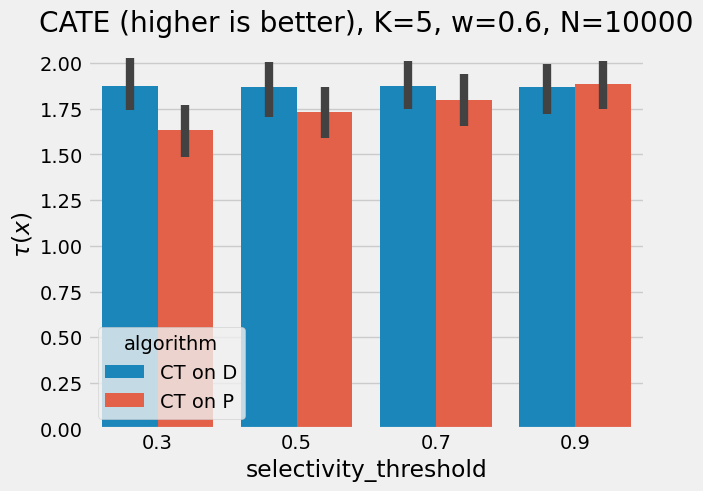

In [2]:
sns.barplot(x='selectivity_threshold', y='t', hue='algorithm', data=scores)
plt.title(f"CATE (higher is better), K={str(K)}, w={str(w)}, N={str(N)}")
plt.ylabel(r"$\tau(x)$")
plt.show()

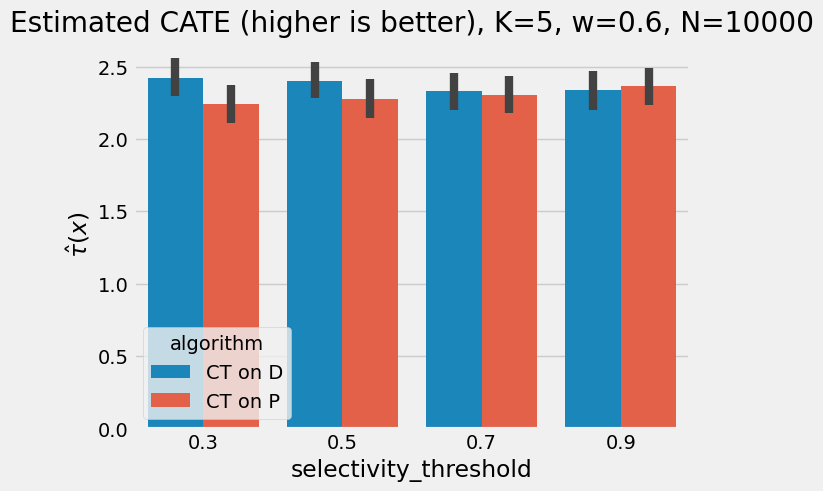

In [3]:
sns.barplot(x='selectivity_threshold', y='t_est', hue='algorithm', data=scores)
plt.title(f"Estimated CATE (higher is better), K={str(K)}, w={str(w)}, N={str(N)}")
plt.ylabel(r"$\hat{{\tau}}(x)$")
plt.show()

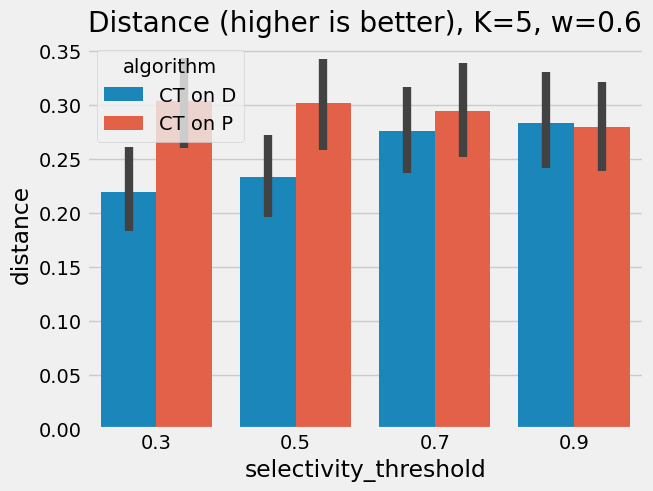

In [4]:
sns.barplot(x='selectivity_threshold', y='distance',hue="algorithm", data=scores)
plt.title(f"Distance (higher is better), K={str(K)}, w={str(w)}")
plt.show()

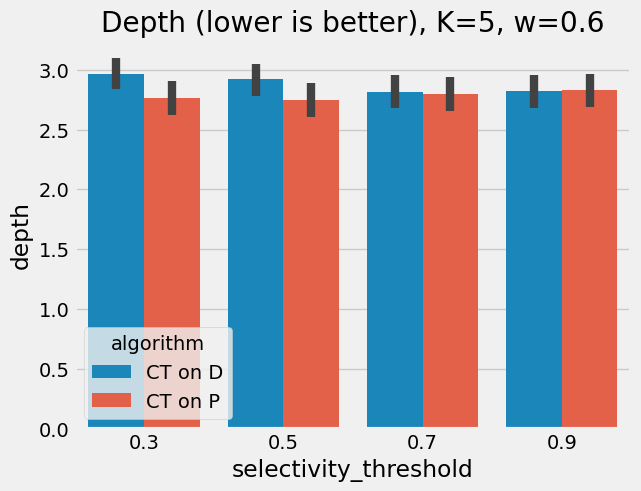

In [5]:
sns.barplot(x='selectivity_threshold', y='depth', hue="algorithm", data=scores)
plt.title(f"Depth (lower is better), K={str(K)}, w={str(w)}")
plt.show()